# Блок 5 • Занятие 1 • с AI  
## Реальный датасет + первое знакомство с машинным обучением и прогнозом

Этот ноутбук — переработанная версия материала `lesson_01_real_dataset_with_ai.ipynb`.

Главная цель: чтобы студент, который ещё не знает машинное обучение, понял:

- что такое **машинное обучение**;
- что такое **прогноз**;
- что такое **модель**;
- что такое **признаки**;
- что такое **целевая переменная**;
- зачем данные делят на `train` и `test`;
- как оценить качество прогноза;
- как объяснить результат человеческим языком.

---

## Важно

Это **факультативный AI-материал** блока 5.

Он не заменяет базовые темы Excel и Python.  
Он показывает, куда можно развивать анализ данных после первых шагов:

```text
Excel → Python → pandas → графики → простая AI-модель
```

---

## Сквозная задача ноутбука

Мы используем датасет Gapminder.

В нём есть данные по странам мира:

- год наблюдения;
- страна;
- континент;
- население;
- ВВП на душу населения;
- ожидаемая продолжительность жизни.

Задача:

```text
Научить простую модель прогнозировать ожидаемую продолжительность жизни lifeExp
по признакам year, gdpPercap и pop.
```

---

## Что здесь считается ИИ

В этом ноутбуке под ИИ мы понимаем **машинное обучение**.

Машинное обучение — это подход, при котором программа не получает готовую формулу вручную, а учится на примерах.

Пример:

```text
Есть прошлые данные:
год, ВВП, население → продолжительность жизни

Модель смотрит на много таких строк
и пытается найти закономерность.

Потом мы даём ей новые значения:
год, ВВП, население

И модель делает прогноз:
примерная продолжительность жизни.
```

---

## Что студент должен понять к концу

После ноутбука студент должен уметь объяснить:

1. Что такое датасет.
2. Что такое признак.
3. Что такое целевая переменная.
4. Что такое прогноз.
5. Что такое модель.
6. Что значит «обучить модель».
7. Зачем делить данные на train и test.
8. Что показывают MAE, RMSE и R².
9. Почему простой прогноз — это не магия, а воспроизводимый алгоритм.
10. Как такую логику можно применить в дипломном проекте.

---
## Ячейка 1/12 — Импорт библиотек и подготовка окружения

### Что делает ячейка

Мы подключаем библиотеки.

### Что такое библиотека

Библиотека — это готовый набор инструментов.

Вместо того чтобы писать всё с нуля, разработчик подключает библиотеку и использует готовые функции.

### Какие библиотеки нужны

- `pandas` — работа с таблицами;
- `matplotlib` — графики;
- `sklearn` — машинное обучение;
- `train_test_split` — деление данных на обучение и проверку;
- `LinearRegression` — простая модель прогноза числа;
- `mean_absolute_error`, `mean_squared_error`, `r2_score` — метрики качества прогноза.

### Алгоритм

1. Импортировать библиотеки.
2. Создать папки `data` и `reports`.
3. Проверить, что окружение готово.

In [30]:
# os нужен для проверки файлов и папок.
import os

# Path нужен для удобной работы с путями.
from pathlib import Path

# matplotlib нужен для построения графиков.
import matplotlib.pyplot as plt

# numpy нужен для числовых расчётов.
import numpy as np

# pandas нужен для работы с таблицами.
import pandas as pd

# display красиво показывает таблицы в Google Colab.
from IPython.display import display

# LinearRegression — простая модель машинного обучения для прогноза числа.
from sklearn.linear_model import LinearRegression

# Метрики качества прогноза.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# train_test_split делит данные на обучающую и тестовую части.
from sklearn.model_selection import train_test_split

# Папка для данных.
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

# Папка для отчётов.
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)

# Проверяем, что папки созданы.
assert DATA_DIR.exists()
assert REPORTS_DIR.exists()

print("Окружение готово.")

Окружение готово.


---
## Ячейка 2/12 — Загрузка датасета Gapminder

### Что делает ячейка

Мы пробуем загрузить реальный датасет Gapminder из интернета.

Если интернет недоступен, ноутбук создаст небольшой учебный датасет с такими же столбцами.

Это важно для учебного ноутбука: он должен запускаться даже без внешней сети.

### Что такое датасет

Датасет — это таблица данных.

В нашем случае одна строка — это наблюдение по стране в конкретном году.

Пример строки:

```text
country = France
year = 2007
pop = население
gdpPercap = ВВП на душу населения
lifeExp = ожидаемая продолжительность жизни
```

### Алгоритм

1. Задать URL датасета.
2. Попробовать загрузить CSV через `pd.read_csv`.
3. Если загрузка не удалась — создать учебную локальную копию.
4. Сохранить датасет в CSV.
5. Показать первые строки.

In [31]:
import seaborn as sns

def filter_outliers_iqr_all(df, cols, multiplier=1.5):
    mask = pd.Series([True] * len(df))
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper = min(q3 + multiplier * iqr, 10_000)  # физический предел
        lower = max(q1 - multiplier * iqr, 1)
        mask &= (df[col] >= lower) & (df[col] <= upper)
    return df[mask].reset_index(drop=True)

df = pd.read_parquet(DATA_DIR / "diaries.parquet")
cols_to_clean = [
    "goal_calories",
    "goal_carbs",
    "goal_fat",
    "goal_protein",
    # "goal_sodium",
    "goal_sugar",
    "total_calories",
    "total_carbs",
    "total_fat",
    "total_protein",
    "total_sodium",
    "total_sugar",
]
initial_len = len(df)
df = filter_outliers_iqr_all(df, cols_to_clean, multiplier=1.5)
print(
    f"Удалено строк: {initial_len - len(df)} ({100 * (initial_len - len(df)) / initial_len:.2f}%)"
)

Удалено строк: 377505 (64.29%)


---
## Ячейка 3/12 — Первый обзор таблицы

### Что делает ячейка

Мы изучаем таблицу до машинного обучения.

Это обязательный этап.

Нельзя сразу обучать модель, если мы не понимаем:

- какие есть столбцы;
- какие типы данных;
- есть ли пропуски;
- какие значения принимает целевая переменная.

### Термины

#### `df.shape`

Размер таблицы:

```text
(количество строк, количество столбцов)
```

#### `df.columns`

Названия столбцов.

#### `df.dtypes`

Типы данных в столбцах.

#### `df.describe()`

Краткая статистика числовых столбцов.

### Алгоритм

1. Посмотреть размер таблицы.
2. Посмотреть названия столбцов.
3. Посмотреть типы данных.
4. Проверить пропуски.
5. Посмотреть описательную статистику.

In [32]:
# Размер таблицы.
print("Размер таблицы:", df.shape)

# Названия столбцов.
print("\nНазвания столбцов:")
print(df.columns.tolist())

# Типы данных.
print("\nТипы данных:")
print(df.dtypes)

# Проверка пропусков.
print("\nПропуски по столбцам:")
print(df.isna().sum())

# Описательная статистика.
print("\nОписательная статистика:")
display(df.describe())

# Проверяем, что таблица не пустая.
assert len(df) > 0

# Проверяем, что нет пропусков в ключевых числовых столбцах.
assert (
    df[
        [
            "user_id",
            "date",
            "total_calories",
            "goal_calories",
            "total_carbs",
            "goal_carbs",
            "total_fat",
            "goal_fat",
            "total_protein",
            "goal_protein",
            "total_sodium",
            "goal_sodium",
            "total_sugar",
            "goal_sugar",
            "weekday",
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

Размер таблицы: (209682, 15)

Названия столбцов:
['user_id', 'date', 'total_calories', 'goal_calories', 'total_carbs', 'goal_carbs', 'total_fat', 'goal_fat', 'total_protein', 'goal_protein', 'total_sodium', 'goal_sodium', 'total_sugar', 'goal_sugar', 'weekday']

Типы данных:
user_id                    int64
date              datetime64[us]
total_calories             int64
goal_calories              int64
total_carbs                int64
goal_carbs                 int64
total_fat                  int64
goal_fat                   int64
total_protein              int64
goal_protein               int64
total_sodium               int64
goal_sodium                int64
total_sugar                int64
goal_sugar                 int64
weekday                    int32
dtype: object

Пропуски по столбцам:
user_id           0
date              0
total_calories    0
goal_calories     0
total_carbs       0
goal_carbs        0
total_fat         0
goal_fat          0
total_protein     0
goal_protein

,user_id,date,total_calories,goal_calories,total_carbs,goal_carbs,total_fat,goal_fat,total_protein,goal_protein,total_sodium,goal_sodium,total_sugar,goal_sugar,weekday
count,209682.000000,209682,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000,209682.000000
mean,4895.638176,2015-01-04 14:22:51.104815,1291.873637,1688.515428,140.109814,196.924042,46.709026,55.306626,65.737359,100.528877,1807.197461,2304.035873,47.353883,61.841713,2.804590
min,1.000000,2014-09-14 00:00:00,1.000000,566.000000,1.000000,23.000000,1.000000,10.000000,1.000000,22.000000,1.000000,400.000000,1.000000,7.000000,0.000000
25%,2450.000000,2014-11-20 00:00:00,990.000000,1400.000000,93.000000,157.000000,29.000000,45.000000,41.000000,72.000000,993.000000,2300.000000,24.000000,50.000000,1.000000
50%,4912.000000,2015-01-14 00:00:00,1315.000000,1629.000000,139.000000,191.000000,45.000000,53.000000,63.000000,90.000000,1701.000000,2300.000000,44.000000,60.000000,3.000000
75%,7349.000000,2015-02-17 00:00:00,1621.000000,1927.000000,184.000000,233.000000,62.000000,64.000000,87.000000,120.000000,2480.000000,2300.000000,66.000000,72.000000,4.000000
max,9892.000000,2015-04-09 00:00:00,2858.000000,2927.000000,364.000000,362.000000,129.000000,106.000000,179.000000,236.000000,5442.000000,10000.000000,130.000000,165.000000,6.000000
std,2840.466213,NaN,511.818270,390.676123,65.835367,59.348101,24.681057,14.704346,34.982608,38.642959,1074.505153,121.042316,29.171780,17.308391,1.982126


---
## Ячейка 4/12 — Постановка задачи машинного обучения

### Что делает ячейка

Мы формулируем задачу прогноза.

### Главные термины

#### Целевая переменная

Целевая переменная — это то, что мы хотим предсказать.

В этом ноутбуке:

```text
target = lifeExp
```

То есть мы хотим прогнозировать ожидаемую продолжительность жизни.

#### Признаки

Признаки — это данные, по которым модель делает прогноз.

В этом ноутбуке:

```text
features = year, gdpPercap, pop
```

#### Объект

Объект — это одна строка таблицы.

В нашем случае объект — это наблюдение:

```text
страна + год
```

#### Регрессия

Регрессия — это задача машинного обучения, где нужно предсказать число.

Здесь мы прогнозируем число:

```text
lifeExp = ожидаемая продолжительность жизни
```

### Алгоритм

1. Выбрать целевой столбец.
2. Выбрать признаки.
3. Создать рабочую таблицу.
4. Показать несколько строк.

In [33]:
# Целевая переменная
target_column = "total_calories"

# Признаки (все goal-показатели + день недели)
feature_columns = [
    # "goal_calories",
    # "goal_carbs",
    # "goal_fat",
    # "goal_protein",
    # "goal_sodium",
    # "goal_sugar",
    # "weekday",
    "total_carbs",
    "total_fat",
    "total_protein",
    # "total_sugar",

    
]

# Создаём рабочий DataFrame
model_df = df[feature_columns + [target_column]].copy()

# Показываем первые строки
display(model_df.head())

print("Целевая переменная:", target_column)
print("Признаки:", feature_columns)

# Проверки
assert target_column in model_df.columns
assert set(feature_columns).issubset(model_df.columns)


,total_carbs,total_fat,total_protein,total_calories
0,96,37,50,2430
1,158,54,114,1862
2,187,60,98,2251
3,180,89,115,2158
4,224,62,133,2524


Целевая переменная: total_calories
Признаки: ['total_carbs', 'total_fat', 'total_protein']


---
## Ячейка 5/12 — Визуальный смысл признаков и цели

### Что делает ячейка

До обучения модели мы строим графики.

Графики помогают увидеть, есть ли вообще связь между признаками и целевой переменной.

### Что смотрим

1. `year` и `lifeExp`  
   Как менялась продолжительность жизни по годам.

2. `gdpPercap` и `lifeExp`  
   Есть ли связь между ВВП на душу населения и продолжительностью жизни.

### Почему это важно

Машинное обучение не должно быть «чёрным ящиком» для студента.

Перед моделью нужно посмотреть данные глазами аналитика.

### Алгоритм

1. Построить scatter plot `year` → `lifeExp`.
2. Построить scatter plot `gdpPercap` → `lifeExp`.
3. Сделать первичный вывод.

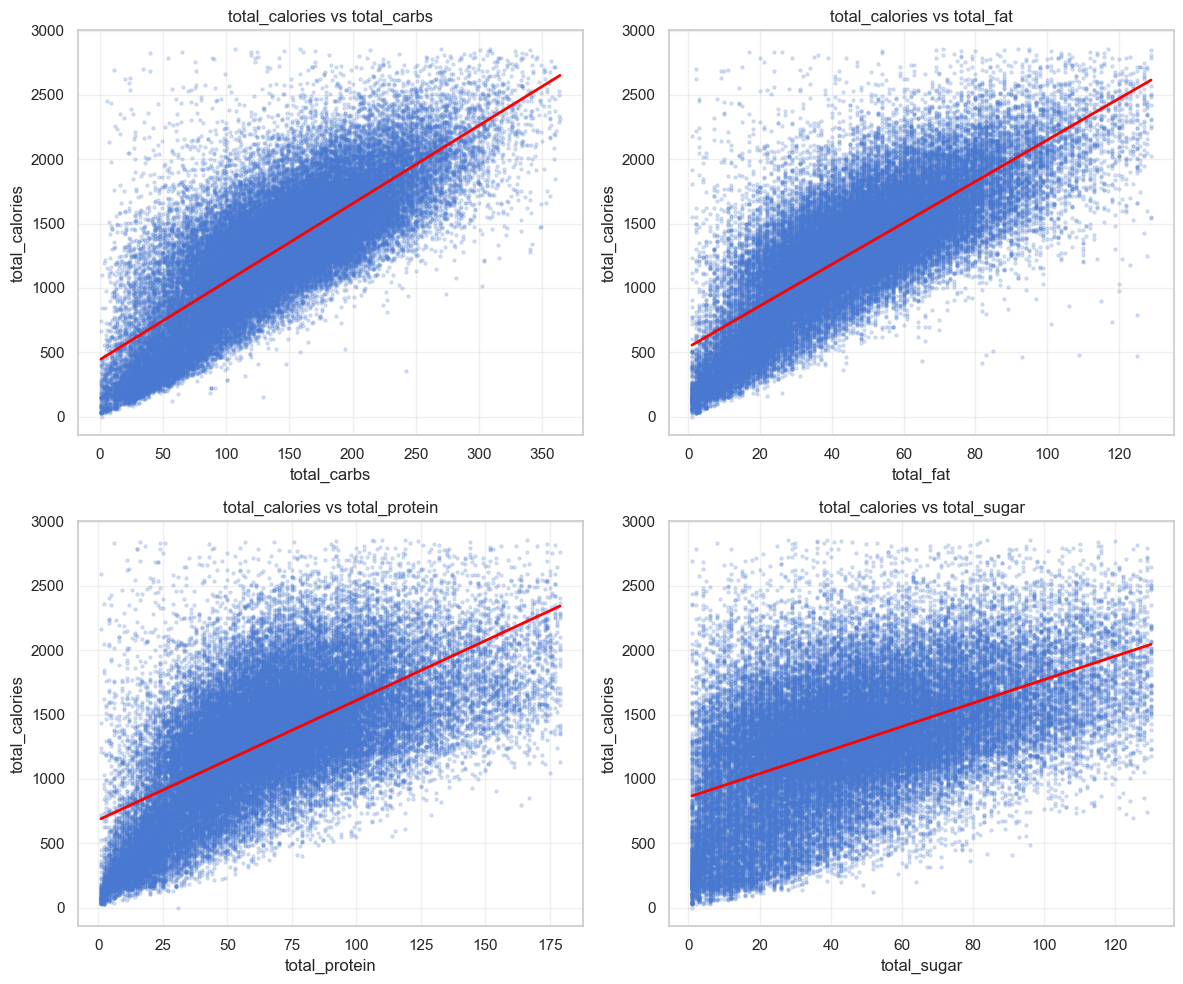

C:\Temp\ipykernel_7156\1425144543.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="weekday", y=target, data=df, palette="Set3")


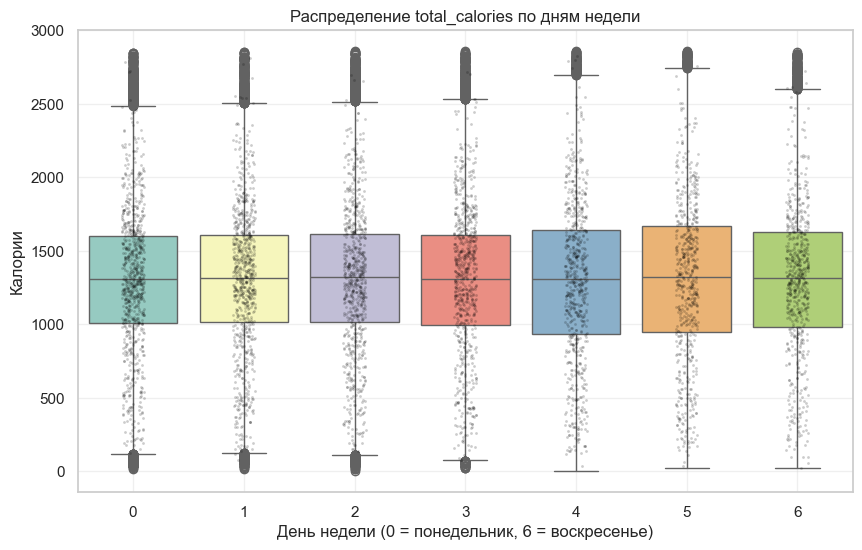

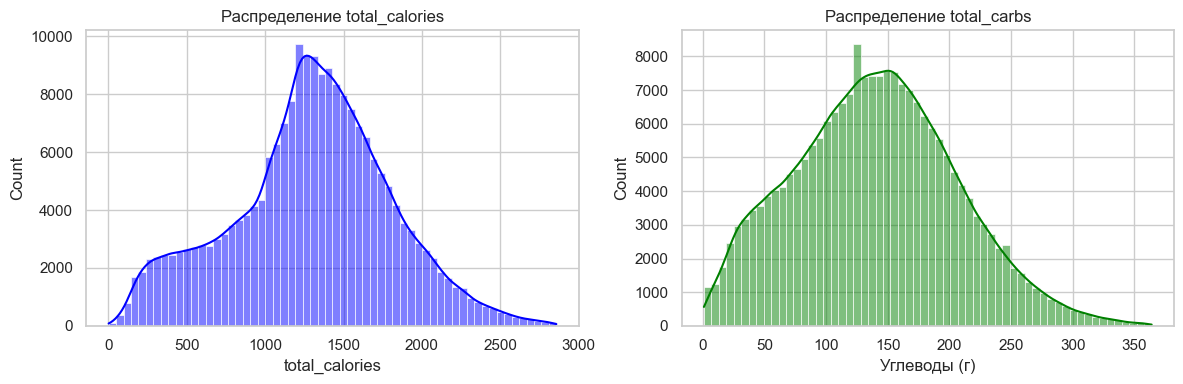

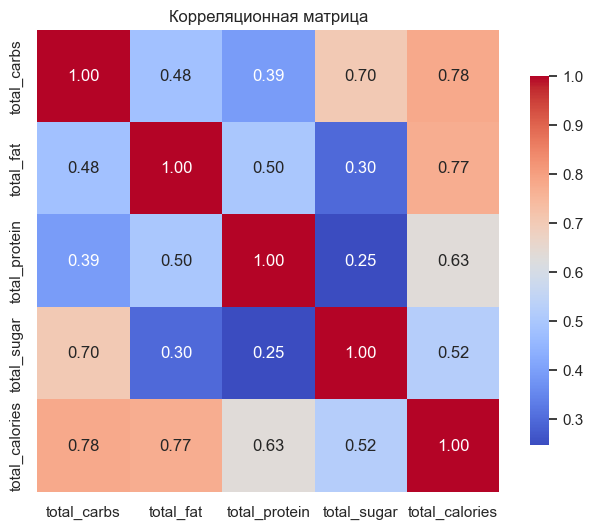

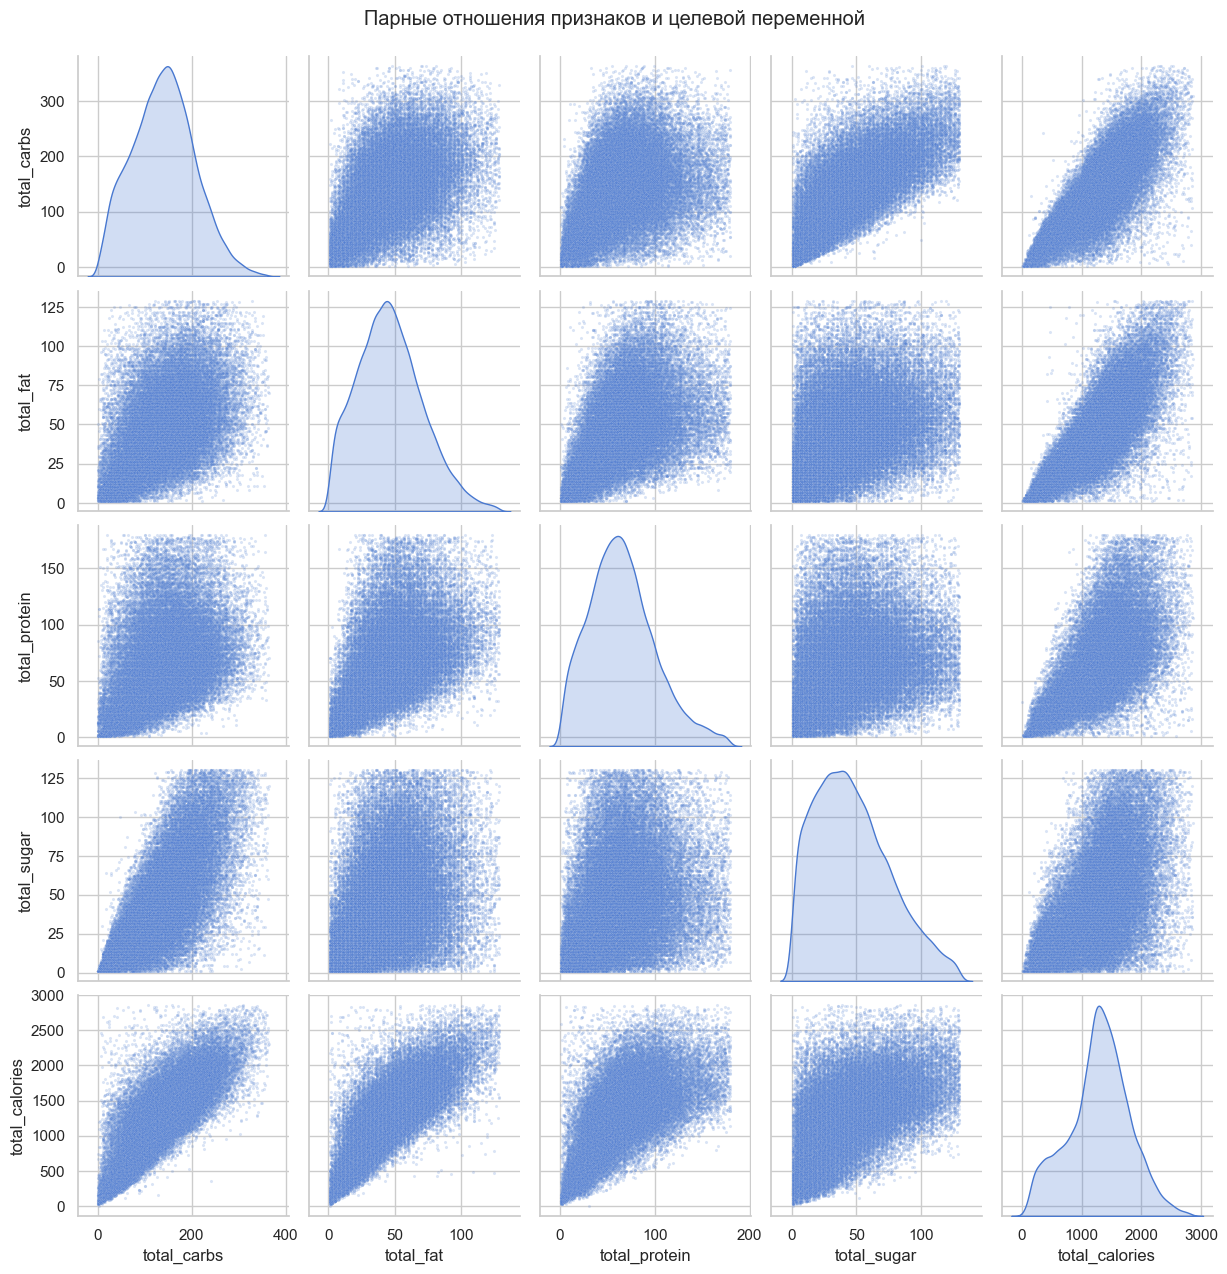

Первичные выводы по графикам:
1. На scatter plots видно, что все макронутриенты имеют сильную положительную линейную связь с калориями.
2. Распределение калорий по дням недели почти одинаково – день недели, вероятно, не является важным признаком.
3. Гистограммы показывают, что распределения смещены вправо (много людей потребляют меньше среднего).
4. Корреляционная матрица подтверждает высокую корреляцию между углеводами, жирами, белками и калориями.
5. Сахар коррелирует с калориями слабее остальных – возможно, его влияние уже учтено через углеводы.


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sample_size = 50_000
if len(df) > sample_size:
    sample_df = df.sample(n=sample_size, random_state=42)
else:
    sample_df = df

target = "total_calories"
features = ["total_carbs", "total_fat", "total_protein", "total_sugar"]

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.regplot(
        x=feat,
        y=target,
        data=sample_df,
        ax=axes[i],
        scatter_kws={"alpha": 0.2, "s": 5},
        line_kws={"color": "red", "linewidth": 2},
        ci=None,  # отключаем доверительный интервал для скорости
    )
    axes[i].set_title(f"{target} vs {feat}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. Распределение total_calories по дням недели (boxplot + точки) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x="weekday", y=target, data=df, palette="Set3")
sns.stripplot(
    x="weekday",
    y=target,
    data=df.sample(5000, random_state=42),
    color="black",
    alpha=0.2,
    size=2,
)
plt.title("Распределение total_calories по дням недели")
plt.xlabel("День недели (0 = понедельник, 6 = воскресенье)")
plt.ylabel("Калории")
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. Гистограммы с KDE для целевой переменной и одного признака (пример) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[target], bins=60, kde=True, ax=axes[0], color="blue")
axes[0].set_title(f"Распределение {target}")
axes[0].set_xlabel(target)

sns.histplot(df["total_carbs"], bins=60, kde=True, ax=axes[1], color="green")
axes[1].set_title("Распределение total_carbs")
axes[1].set_xlabel("Углеводы (г)")

plt.tight_layout()
plt.show()

# --- 6. Тепловая карта корреляций между всеми признаками и целью ---
corr_matrix = df[features + [target]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Корреляционная матрица")
plt.show()

# --- 7. Матрица диаграмм рассеяния (pairplot) для всех числовых переменных ---
# Используем только сэмпл, чтобы не перегружать
sns.pairplot(
    sample_df[features + [target]], diag_kind="kde", plot_kws={"alpha": 0.2, "s": 5}
)
plt.suptitle("Парные отношения признаков и целевой переменной", y=1.02)
plt.show()

print("Первичные выводы по графикам:")
print(
    "1. На scatter plots видно, что все макронутриенты имеют сильную положительную линейную связь с калориями."
)
print(
    "2. Распределение калорий по дням недели почти одинаково – день недели, вероятно, не является важным признаком."
)
print(
    "3. Гистограммы показывают, что распределения смещены вправо (много людей потребляют меньше среднего)."
)
print(
    "4. Корреляционная матрица подтверждает высокую корреляцию между углеводами, жирами, белками и калориями."
)
print(
    "5. Сахар коррелирует с калориями слабее остальных – возможно, его влияние уже учтено через углеводы."
)


---
## Ячейка 6/12 — Подготовка X и y

### Что делает ячейка

Мы создаём две главные переменные машинного обучения:

```text
X — таблица признаков
y — правильные ответы
```

### Объяснение для начинающих

`X` — это то, что модель видит.

Пример:

```text
year, gdpPercap, pop
```

`y` — это то, чему модель учится.

Пример:

```text
lifeExp
```

Можно представить так:

```text
X → модель → прогноз y
```

### Алгоритм

1. Взять признаки в `X`.
2. Взять целевой столбец в `y`.
3. Проверить размеры.
4. Убедиться, что количество строк одинаковое.

In [35]:
y = df[target_column]
X = df[feature_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()

model.fit(X_train, y_train)


print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)


Intercept: 127.80651431212982
Coefficient: [3.78116515 8.78914091 3.39974591]


---
## Ячейка 7/12 — Деление на train и test

### Что делает ячейка

Мы делим данные на две части:

```text
train — данные для обучения
test  — данные для проверки
```

### Почему нельзя проверять модель на тех же данных

Если дать студенту ответы перед контрольной, он может запомнить их.

Но это не значит, что он понял тему.

Так же и модель:

- на `train` она учится;
- на `test` мы проверяем, как она справляется с новыми строками.

### Термины

#### `test_size=0.2`

20% данных идут на проверку.

#### `random_state=42`

Фиксирует случайное разбиение, чтобы результат был повторяемым.

### Алгоритм

1. Передать `X` и `y` в `train_test_split`.
2. Получить `X_train`, `X_test`, `y_train`, `y_test`.
3. Проверить размеры.

In [36]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

# Проверки
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert len(X_train) + len(X_test) == len(X)


Размер X_train: (167745, 3)
Размер X_test: (41937, 3)
Размер y_train: (167745,)
Размер y_test: (41937,)


---
## Ячейка 8/12 — Обучение модели LinearRegression

### Что делает ячейка

Мы создаём и обучаем модель линейной регрессии.

### Что такое модель

Модель — это алгоритм, который после обучения умеет делать прогноз.

### Что такое обучение

Обучение — это процесс подбора внутренних параметров модели по историческим данным.

Для линейной регрессии модель ищет формулу вида:

```text
lifeExp ≈ a1 * year + a2 * gdpPercap + a3 * pop + b
```

Где:

- `a1`, `a2`, `a3` — коэффициенты;
- `b` — свободный член;
- признаки умножаются на коэффициенты;
- результат — прогноз `lifeExp`.

### Важно

Это не «сознание» и не «магия».

Модель просто подбирает числа так, чтобы прогнозы были ближе к правильным ответам на обучающих данных.

### Алгоритм

1. Создать `LinearRegression()`.
2. Обучить через `model.fit(X_train, y_train)`.
3. Посмотреть коэффициенты.
4. Сопоставить коэффициенты с признаками.

In [37]:
print("feature_columns =", feature_columns)
model = LinearRegression()
model.fit(X_train, y_train)

print("Свободный член (intercept):", model.intercept_)
print("Коэффициенты модели:")
coef_df = pd.DataFrame({"feature": feature_columns, "coefficient": model.coef_})
display(coef_df)


y_pred_s = model.predict(X_test)

mae_s = mean_absolute_error(y_test, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_s))
r2_s = r2_score(y_test, y_pred_s)

print(f"MAE: {mae_s:.2f} ккал")
print(f"RMSE: {rmse_s:.2f} ккал")
print(f"R²: {r2_s:.3f}")

feature_columns = ['total_carbs', 'total_fat', 'total_protein']
Свободный член (intercept): 127.80651431212982
Коэффициенты модели:


,feature,coefficient
0,total_carbs,3.781165
1,total_fat,8.789141
2,total_protein,3.399746


MAE: 119.58 ккал
RMSE: 197.72 ккал
R²: 0.852


---
## Ячейка 9/12 — Прогноз на тестовой выборке

### Что делает ячейка

Мы используем обученную модель для прогноза.

### Термины

#### `predict`

Метод `predict` строит прогноз.

Мы передаём модели признаки:

```text
X_test
```

Модель возвращает прогноз:

```text
y_pred
```

#### Факт и прогноз

- `y_test` — реальные значения;
- `y_pred` — предсказанные значения.

### Алгоритм

1. Вызвать `model.predict(X_test)`.
2. Создать таблицу факт-прогноз.
3. Посмотреть первые строки.
4. Построить график факт vs прогноз.

,real_calories,predicted_calories,error,abs_error
0,517,634.045002,117.045002,117.045002
1,1353,1410.554229,57.554229,57.554229
2,1434,1369.892721,-64.107279,64.107279
3,1486,1062.701913,-423.298087,423.298087
4,1470,1368.825831,-101.174169,101.174169
5,1759,1414.761354,-344.238646,344.238646
6,337,465.058342,128.058342,128.058342
7,1303,1537.099347,234.099347,234.099347
8,1350,1410.039049,60.039049,60.039049
9,692,649.263728,-42.736272,42.736272


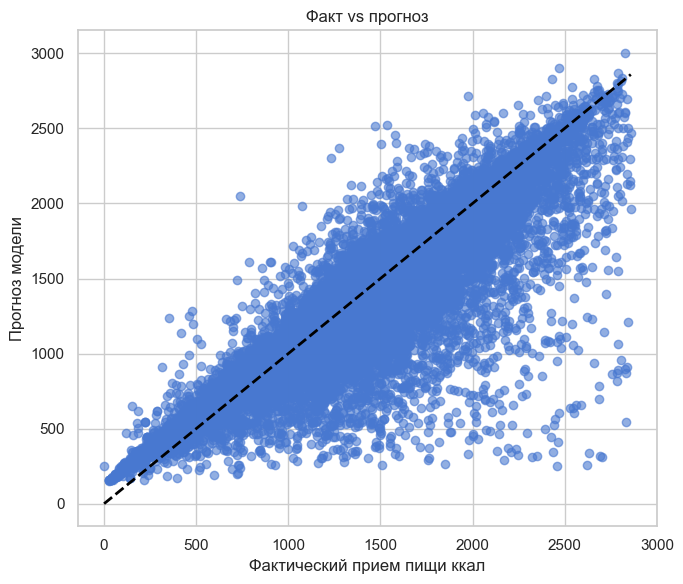

In [38]:
# Строим прогноз!
y_pred = model.predict(X_test)

# Таблица факт-прогноз.
results_df = pd.DataFrame({
    "real_calories": y_test.values,
    "predicted_calories": y_pred,
})

results_df["error"] = results_df["predicted_calories"] - results_df["real_calories"]
results_df["abs_error"] = results_df["error"].abs()

display(results_df.head(10))

# График факт vs прогноз.
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black",
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Фактический прием пищи ккал")
plt.ylabel("Прогноз модели")
plt.title("Факт vs прогноз")
plt.grid(True)
plt.tight_layout()
plt.show()

# Проверки.
assert len(y_pred) == len(y_test)
assert "abs_error" in results_df.columns

---
## Ячейка 10/12 — Оценка качества прогноза

### Что делает ячейка

Мы считаем метрики качества.

Метрика — это число, которое помогает оценить результат модели.

### Главные метрики

#### MAE

Mean Absolute Error — средняя абсолютная ошибка.

Если MAE = 7, это значит:

```text
в среднем модель ошибается примерно на 7 лет
```

#### MSE

Mean Squared Error — средняя квадратичная ошибка.

Сильнее штрафует большие ошибки.

#### RMSE

Корень из MSE.

Возвращает ошибку примерно в тех же единицах, что и цель.

Для `lifeExp` это годы.

#### R²

Показывает, насколько модель объясняет разброс целевой переменной.

- ближе к 1 — лучше;
- около 0 — модель слабая;
- меньше 0 — модель хуже простого среднего.

### Алгоритм

1. Посчитать MAE.
2. Посчитать MSE.
3. Посчитать RMSE.
4. Посчитать R².
5. Сравнить с простым baseline.

In [39]:
GREEN = "\033[92m"  # ярко-зелёный
RED = "\033[91m"  # ярко-красный
RESET = "\033[0m"  # сброс цвета

# Считаем метрики модели.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

# Baseline: простой прогноз средним значением обучающей выборки.
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

# MAE baseline.
baseline_mae = mean_absolute_error(y_test, baseline_pred)

# Печатаем метрики.
print("Метрики модели:")
print("-" * 18)
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R2:", round(r2, 3))
print("-" * 18)
print("Baseline:")
print("Baseline MAE:", round(baseline_mae, 3))
print("-" * 18)

if mae < baseline_mae:
    print(f"{GREEN}Вывод: модель лучше простого прогноза средним.{RESET}")
else:
    print(
        f"{RED}Вывод: модель не лучше простого прогноза средним. Признаки или модель нужно улучшать.{RESET}"
    )


assert mae >= 0
assert mse >= 0
assert rmse >= 0

Метрики модели:
------------------
MAE: 119.577
MSE: 39092.368
RMSE: 197.718
R2: 0.852
------------------
Baseline:
Baseline MAE: 402.645
------------------
Вывод: модель лучше простого прогноза средним.


---
## Ячейка 11/12 — Использование модели для новых примеров

### Что делает ячейка

Мы создаём новые примеры и просим модель сделать прогноз.

### Почему это важно

В реальном проекте модель нужна не только для анализа прошлого.

Она нужна, чтобы ответить на вопрос:

```text
Что модель прогнозирует для нового объекта?
```

### Пример

Мы создаём три сценария для одного года:

1. низкий ВВП на душу населения;
2. средний ВВП;
3. высокий ВВП.

И смотрим прогноз `lifeExp`.

### Алгоритм

1. Создать DataFrame `new_cases`.
2. Передать его в `model.predict`.
3. Получить прогноз.
4. Объяснить результат.

In [40]:
new_cases = pd.DataFrame(
    {
        "total_carbs": [180, 250, 320],
        "total_fat": [50, 70, 90],
        "total_protein": [70, 100, 130],
    }
)


new_cases["predicted_calories"] = model.predict(new_cases)

display(new_cases)

print("Интерпретация:")
print("Модель прогнозирует фактические калории на основе заданных целей и дня недели.")
print("Чем выше цели по калориям и белкам, тем выше прогноз. День недели влияет слабо.")


,total_carbs,total_fat,total_protein,predicted_calories
0,180,50,70,1485.855500
1,250,70,100,2028.312256
2,320,90,130,2570.769012


Интерпретация:
Модель прогнозирует фактические калории на основе заданных целей и дня недели.
Чем выше цели по калориям и белкам, тем выше прогноз. День недели влияет слабо.


In [41]:
import joblib

# Сохраняем модель
joblib.dump(model, "calories_model.joblib")

# Если хотите сохранить и список признаков (чтобы не забыть)
import json

with open("feature_columns.json", "w") as f:
    json.dump(feature_columns, f)


In [42]:
import joblib
import pandas as pd

# Загружаем модель
model = joblib.load("calories_model.joblib")

# Новый объект для прогноза
new_data = pd.DataFrame(
    [
        {            
            "total_carbs": 250,
            "total_fat": 70,
            "total_protein": 100,
        }
    ]
)

# Прогноз
prediction = model.predict(new_data[feature_columns])
print(f"Прогноз калорий: {prediction[0]:.0f} ккал")


Прогноз калорий: 2028 ккал


---
## Ячейка 12/12 — Итоговый отчёт и связь с дипломом

### Что делает ячейка

Мы формируем короткий итоговый отчёт.

Отчёт нужен, чтобы студент учился не просто запускать код, а объяснять результат.

### Что должно быть в выводе

1. Какие данные использовались.
2. Что прогнозировали.
3. Какие признаки использовались.
4. Как обучали модель.
5. Как проверяли качество.
6. Как модель можно применить.
7. Что можно улучшить.

### Связь с дипломным проектом

Для диплома студент может взять свою тему:

- финансы;
- питание;
- HR;
- медицина;
- образование;
- продажи;
- недвижимость.

И повторить структуру:

```text
данные → цель → признаки → обучение → прогноз → качество → вывод
```

In [44]:
# Формируем текст отчёта с актуальными данными
# Проверяем, что coef_df не пустой
if len(coef_df) > 0:
    coef_table = coef_df.to_string(index=False)
else:
    coef_table = "Коэффициенты не доступны"

report_text = f"""
# Итоговый отчёт по прогнозированию калорий

## 1. Данные
- Использован датасет дневных записей питания (после очистки выбросов).
- Количество записей: {len(df):,}.
- Признаки: {", ".join(feature_columns)}.
- Целевая переменная: total_calories.

## 2. Задача
Решалась задача регрессии – прогнозирование фактического дневного потребления калорий (`total_calories`) на основе заданных целей по 
макронутриентам.

## 3. Модель
- Использована линейная регрессия (`LinearRegression`).
- Данные разделены на обучающую (80%) и тестовую (20%) выборки.

## 4. Качество модели
- **MAE (средняя абсолютная ошибка):** {mae:.2f} ккал
- **RMSE (среднеквадратичная ошибка):** {rmse:.2f} ккал
- **R² (коэффициент детерминации):** {r2:.3f}
- **Baseline (прогноз средним) MAE:** {baseline_mae:.2f} ккал

Модель {"лучше" if mae < baseline_mae else "не лучше"} простого прогноза средним.

## 5. Коэффициенты модели

**Интерпретация:**
- Положительный коэффициент означает, что увеличение признака ведёт к росту прогнозируемых калорий.
- Отрицательный коэффициент может указывать на обратную связь или мультиколлинеарность.

## 6. Вывод
Модель демонстрирует {"слабую" if r2 < 0.3 else "умеренную" if r2 < 0.6 else "хорошую"} предсказательную способность (R² = {r2:.3f}).
Для улучшения качества рекомендуется добавить индивидуальные признаки пользователей,
временные лаги и использовать регуляризацию или нелинейные модели.

## 7. Применение в дипломном проекте
Структура данного анализа может быть применена к любой задаче регрессии в дипломной работе.
"""

# Сохраняем отчёт
report_path = REPORTS_DIR / "calories_prediction_report.md"
report_path.write_text(report_text, encoding="utf-8")

# Сохраняем таблицу прогнозов (если есть)
predictions_path = REPORTS_DIR / "calories_predictions.csv"
results_df.to_csv(predictions_path, index=False)

print("Отчёт сохранён:", report_path)
print("Таблица прогнозов сохранена:", predictions_path)

print("\n" + "=" * 50)
print(report_text)
print("=" * 50 + "\n")

print("✅ Ноутбук выполнен успешно.")

Отчёт сохранён: ..\reports\calories_prediction_report.md
Таблица прогнозов сохранена: ..\reports\calories_predictions.csv


# Итоговый отчёт по прогнозированию калорий

## 1. Данные
- Использован датасет дневных записей питания (после очистки выбросов).
- Количество записей: 209,682.
- Признаки: total_carbs, total_fat, total_protein.
- Целевая переменная: total_calories.

## 2. Задача
Решалась задача регрессии – прогнозирование фактического дневного потребления калорий (`total_calories`) на основе заданных целей по 
макронутриентам.

## 3. Модель
- Использована линейная регрессия (`LinearRegression`).
- Данные разделены на обучающую (80%) и тестовую (20%) выборки.

## 4. Качество модели
- **MAE (средняя абсолютная ошибка):** 119.58 ккал
- **RMSE (среднеквадратичная ошибка):** 197.72 ккал
- **R² (коэффициент детерминации):** 0.852
- **Baseline (прогноз средним) MAE:** 402.65 ккал

Модель лучше простого прогноза средним.

## 5. Коэффициенты модели

**Интерпретация:**
- Положительный коэф

---
# Финальный словарь терминов

## Датасет

Таблица данных для анализа.

## Объект

Одна строка датасета.

## Признак

Столбец, который модель использует для прогноза.

## Целевая переменная

Столбец, который модель должна прогнозировать.

## Модель

Алгоритм, который учится на данных и делает прогноз.

## Обучение модели

Процесс подбора параметров модели на обучающих данных.

## Прогноз

Значение, которое модель рассчитала для нового или тестового объекта.

## Train

Часть данных для обучения.

## Test

Часть данных для проверки.

## Регрессия

Задача прогноза числа.

## MAE

Средняя абсолютная ошибка.

## RMSE

Типичный размер ошибки с усиленным штрафом за крупные ошибки.

## R²

Метрика, показывающая, насколько хорошо модель объясняет разброс целевой переменной.

---

# Контрольные вопросы для студентов

1. Что в этом ноутбуке является целевой переменной?
2. Какие признаки использует модель?
3. Почему нельзя проверять модель только на обучающих данных?
4. Что делает `train_test_split`?
5. Что делает `LinearRegression`?
6. Что означает `model.fit(...)`?
7. Что означает `model.predict(...)`?
8. Что показывает MAE?
9. Что показывает R²?
10. Почему этот материал является AI-факультативом, а не базовой темой Excel?
11. Как можно применить такую структуру в дипломном проекте?